<a href="https://colab.research.google.com/github/Janya-Sharma-22/neural_networks-KRMU/blob/main/PROJECT_2_%26_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#PROJECT 2

In [1]:
import kagglehub
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras

path = kagglehub.dataset_download("johnsmith88/heart-disease-dataset")

import os
print(os.listdir(path))

file_path = os.path.join(path, "heart.csv")
df = pd.read_csv(file_path)

print(df.head())

X = df.drop("target", axis=1)
y = df["target"]

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = keras.Sequential([
    keras.layers.Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    keras.layers.Dense(8, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=50, validation_split=0.2)

loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

Using Colab cache for faster access to the 'heart-disease-dataset' dataset.
['heart.csv']
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.4848 - loss: 0.7650 - val_accuracy: 0.4756 - val_loss: 0.7477
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5518 - loss: 0.6887 - val_accuracy: 0.5732 - val_loss: 0.6771
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6357 - loss: 0.6365 - val_accuracy: 0.6402 - val_loss: 0.6268
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6951 - loss: 0.5953 - val_accuracy: 0.7012 - val_loss: 0.5848
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7546 - loss: 0.5576 - val_accuracy: 0.7622 - val_loss: 0.5457
Epoch 6/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7942 - loss: 0.5215 - val_accuracy: 0.7927 - val_loss: 0.5091
Epoch 7/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8125 - loss: 0.4871 - val_accuracy: 0.7927 - val_loss: 0.4757
Epoch 8/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8079 - loss: 0.4571 - val_accuracy: 0.7927 - val_loss: 0.4476
Ep

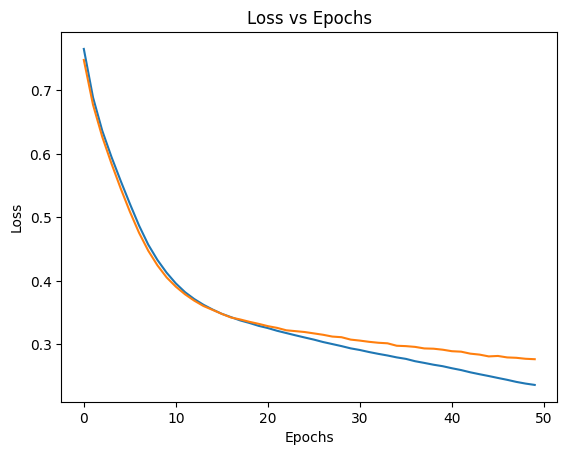

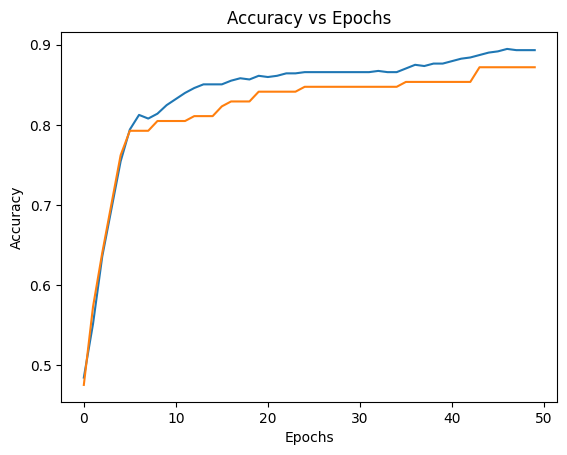

In [2]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')
plt.show()

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epochs')
plt.show()

# PROJECT 3

In [8]:
import kagglehub
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import os

path = kagglehub.dataset_download("bhavikjikadara/dog-and-cat-classification-dataset")
data_dir = os.path.join(path, "PetImages")

img_size = (180, 180)
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

train_ds = train_ds.map(lambda x, y: (tf.image.resize(x, img_size), y))
val_ds = val_ds.map(lambda x, y: (tf.image.resize(x, img_size), y))

train_ds = train_ds.apply(tf.data.experimental.ignore_errors())
val_ds = val_ds.apply(tf.data.experimental.ignore_errors())

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

model = keras.Sequential([
    layers.Rescaling(1./255, input_shape=(180, 180, 3)),

    layers.Conv2D(16, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])


Using Colab cache for faster access to the 'dog-and-cat-classification-dataset' dataset.
Found 24998 files belonging to 2 classes.
Using 19999 files for training.
Found 24998 files belonging to 2 classes.
Using 4999 files for validation.


Instructions for updating:
Use `tf.data.Dataset.ignore_errors` instead.


Epoch 1/10
    618/Unknown 578s 920ms/step - accuracy: 0.5728 - loss: 0.6886

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


618/618 ━━━━━━━━━━━━━━━━━━━━ 623s 993ms/step - accuracy: 0.6339 - loss: 0.6339 - val_accuracy: 0.7227 - val_loss: 0.5361
Epoch 2/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 596s 965ms/step - accuracy: 0.7682 - loss: 0.4841 - val_accuracy: 0.7846 - val_loss: 0.4563
Epoch 3/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 598s 967ms/step - accuracy: 0.8154 - loss: 0.3995 - val_accuracy: 0.7850 - val_loss: 0.4547
Epoch 4/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 606s 980ms/step - accuracy: 0.8689 - loss: 0.3043 - val_accuracy: 0.7960 - val_loss: 0.4850
Epoch 5/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 594s 961ms/step - accuracy: 0.9120 - loss: 0.2106 - val_accuracy: 0.7696 - val_loss: 0.7228
Epoch 6/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 613s 992ms/step - accuracy: 0.9500 - loss: 0.1326 - val_accuracy: 0.7884 - val_loss: 0.8028
Epoch 7/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 605s 979ms/step - accuracy: 0.9684 - loss: 0.0858 - val_accuracy: 0.7902 - val_loss: 0.7681
Epoch 8/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 594s 960ms/step - accuracy: 0.9808 - loss: 0.05

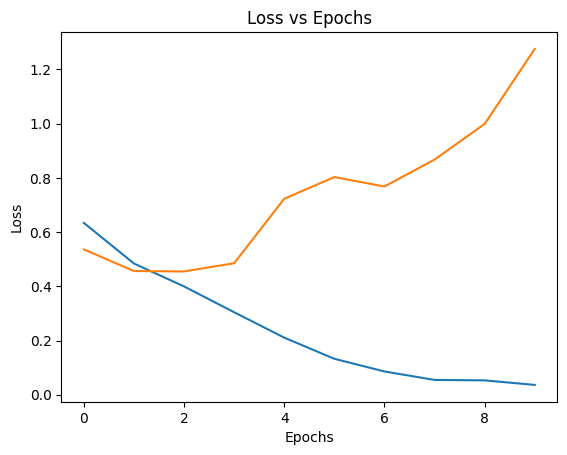

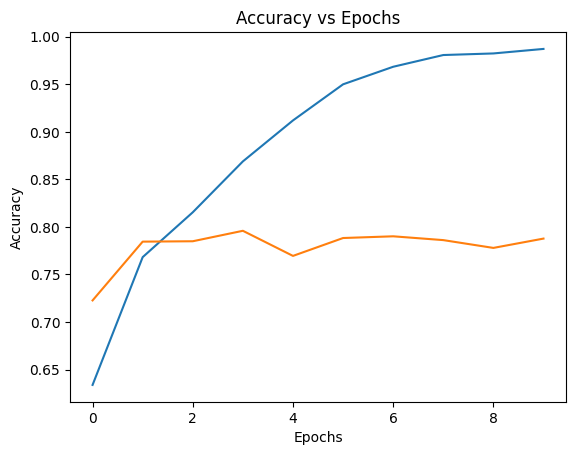

In [9]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')
plt.show()

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epochs')
plt.show()